# Relação aluno-professor e desempenho em distritos escolares da

Califórnia

Washington Santos da Silva [ORCID profile for Washington Santos da Silva](https://orcid.org/0000-0003-2396-3507) (IFMG - Campus Formiga)  
Felipe Luiz Fonsêca (IFMG - Campus Formiga)  
Vinícius Silva Faria (IFMG - Campus Formiga)  
João Vitor Balduino Soares de Melo (IFMG - Campus Arcos)

Este miniestudo examina a associação entre a relação aluno-professor e o desempenho médio em testes padronizados de distritos escolares da Califórnia. São comparados um modelo linear simples e um modelo ajustado pela renda média do distrito e pelo percentual de estudantes aprendizes de inglês. Os resultados mostram que a associação negativa observada no modelo simples é substancialmente atenuada após a inclusão dessas características socioeconômicas. A análise é descritiva e não permite interpretação causal.

In [ ]:
# carrega os dados do pacote AER
data("CASchools", package = "AER")

## Introdução

A relação entre recursos escolares e desempenho discente permanece relevante para a gestão educacional. A literatura mostra, contudo, que associações entre recursos e resultados variam entre contextos e dependem das características dos estudantes e das organizações escolares ([Hanushek, 1997](#ref-hanushek1997)). Estudos sobre tamanho de turma também ressaltam a importância de distinguir associações observadas de estimativas causais ([Angrist e Lavy, 1999](#ref-angristlavy1999)).

Este estudo investiga se distritos escolares com maior número de alunos por professor apresentam desempenho médio diferente nos testes de leitura e matemática.

## Métodos

Foram utilizados os dados `CASchools`, distribuídos pelo pacote R `AER`. O conjunto reúne distritos escolares K–6 e K–8 da Califórnia com informações de 1998 e 1999 ([Kleiber e Zeileis, 2008](#ref-kleiberzeileis2008); [Stock e Watson, 2007](#ref-stockwatson2007)). A unidade de observação é o distrito escolar.

A relação aluno-professor foi calculada dividindo a matrícula total pelo número de professores em equivalentes de tempo integral. O desempenho médio foi calculado como a média dos escores de leitura e matemática do teste Stanford 9.

Foram estimados dois modelos lineares. O Modelo 1 relaciona o desempenho médio apenas à relação aluno-professor. O Modelo 2 acrescenta a renda média do distrito, medida em milhares de dólares, e o percentual de estudantes aprendizes de inglês. Os modelos descrevem associações condicionais e não são interpretados causalmente.

## Resultados

A análise inclui 420 distritos. A relação média é de 19.6 alunos por professor.

A <a href="#tbl-modelos" class="quarto-xref">Tabela 1</a> compara os dois modelos estimados.

``` python
# Organiza os resultados dos dois modelos em uma única tabela.
modelsummary::modelsummary(
  list(
    "Modelo 1" = modelo_1,
    "Modelo 2" = modelo_2
  ),
  output = "markdown",
  coef_map = c(
    "(Intercept)" = "Constante",
    "alunos_por_professor" = "Alunos por professor",
    "income" = "Renda média do distrito (US$ mil)",
    "english" = "Estudantes aprendizes de inglês (%)"
  ),
  statistic = "conf.int",
  gof_map = c("nobs", "r.squared"),
  fmt = 2
)
```

|                                     | Modelo 1           | Modelo 2           |
|-----------------------------------|:-----------------|:-----------------|
| Constante                           | 698.93             | 640.32             |
|                                     | \[680.32, 717.54\] | \[628.96, 651.67\] |
| Alunos por professor                | -2.28              | -0.07              |
|                                     | \[-3.22, -1.34\]   | \[-0.61, 0.48\]    |
| Renda média do distrito (US\$ mil)  |                    | 1.49               |
|                                     |                    | \[1.35, 1.64\]     |
| Estudantes aprendizes de inglês (%) |                    | -0.49              |
|                                     |                    | \[-0.55, -0.43\]   |
| Num.Obs.                            | 420                | 420                |
| R2                                  | 0.051              | 0.707              |

Tabela 1: Associação entre relação aluno-professor e desempenho médio

A comparação entre os modelos mostra que a associação negativa observada no modelo simples é substancialmente atenuada após a inclusão da renda média do distrito e do percentual de estudantes aprendizes de inglês.

A <a href="#fig-relacao-desempenho" class="quarto-xref">Figura 1</a> apresenta a relação observada entre os dois indicadores. A inclinação negativa da linha resume a associação não ajustada e não deve ser interpretada como resultado do Modelo 2.

``` python
# Representa graficamente a relação entre alunos por professor e
# desempenho médio e adiciona a linha de regressão linear.
ggplot2::ggplot(
  dados_escolas,
  ggplot2::aes(x = alunos_por_professor, y = desempenho_medio)
) +
  ggplot2::geom_point(alpha = 0.55, color = "#33658A") +
  ggplot2::geom_smooth(
    method = "lm",
    formula = y ~ x,
    se = TRUE,
    color = "#B23A48",
    fill = "#E9A3AA"
  ) +
  ggplot2::labs(
    x = "Alunos por professor",
    y = "Desempenho médio"
  ) +
  ggplot2::theme_minimal(base_size = 11)
```

<figure id="fig-relacao-desempenho">
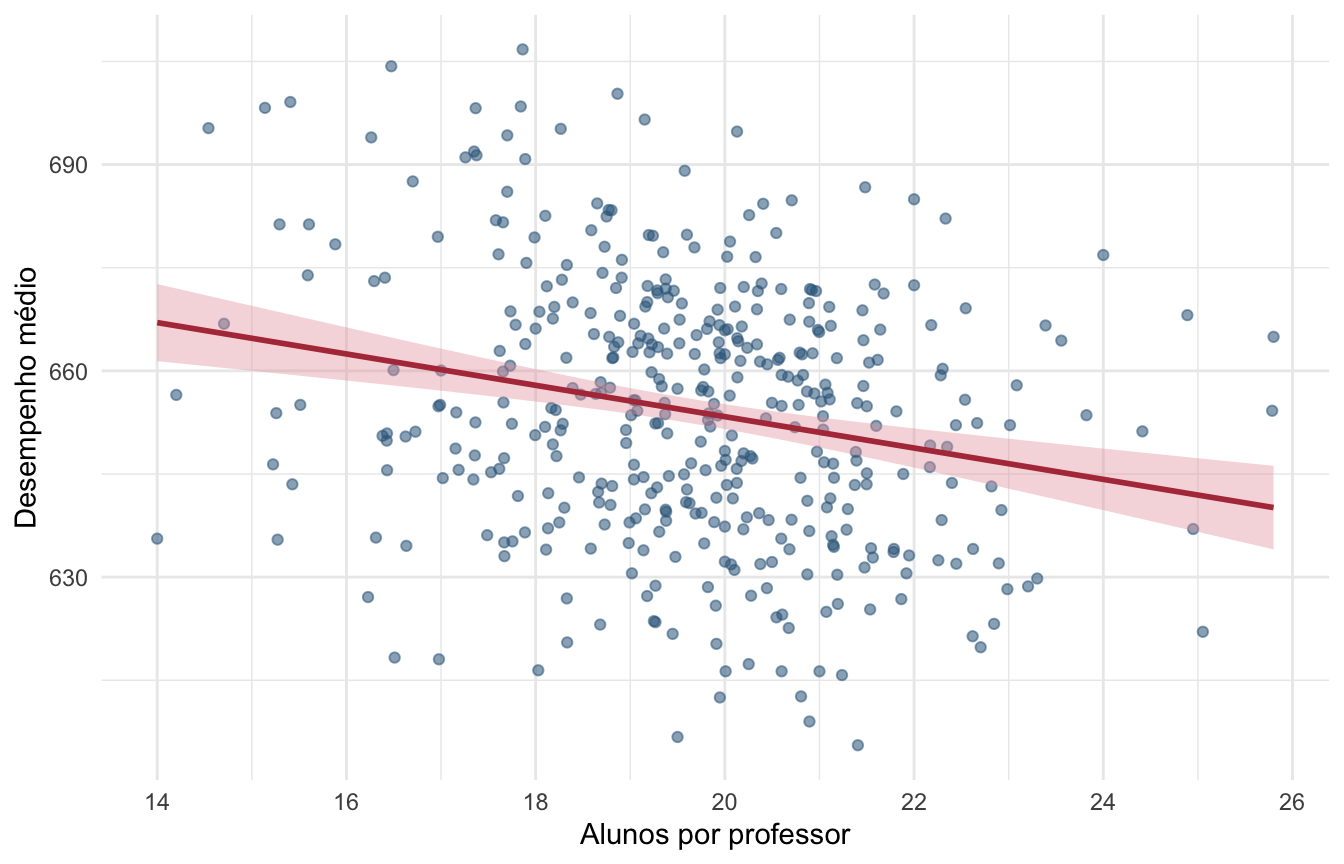
<figcaption>Figura 1: Relação aluno-professor e desempenho médio nos distritos escolares</figcaption>
</figure>

## Discussão

Os distritos com maior relação aluno-professor apresentaram, em média, menor desempenho no modelo simples. Essa associação praticamente desapareceu após a inclusão da renda média distrital e do percentual de estudantes aprendizes de inglês.

O resultado reforça que diferenças socioeconômicas entre distritos podem estar relacionadas simultaneamente à organização dos recursos escolares e ao desempenho. Como o estudo utiliza dados observacionais agregados e uma especificação deliberadamente simples, não é possível atribuir causalidade à relação aluno-professor.

## Referências

ANGRIST, J. D.; LAVY, V. [Using Maimonides’ Rule to Estimate the Effect of Class Size on Scholastic Achievement](https://doi.org/10.1162/003355399556061). **The Quarterly Journal of Economics**, v. 114, n. 2, p. 533–575, 1999.

HANUSHEK, E. A. [Assessing the Effects of School Resources on Student Performance: An Update](https://doi.org/10.3102/01623737019002141). **Educational Evaluation and Policy Analysis**, v. 19, n. 2, p. 141–164, 1997.

KLEIBER, C.; ZEILEIS, A. **[Applied Econometrics with R](https://doi.org/10.1007/978-0-387-77318-6)**. New York: Springer, 2008.

STOCK, J. H.; WATSON, M. W. **Introduction to Econometrics**. 2. ed. Boston: Pearson Addison Wesley, 2007.